<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1 Exercise - 1:
Complete all the Task.
1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.
2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.
3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}
4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lenna.png to Lenna (1).png


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
image = Image.open("Lenna.png")

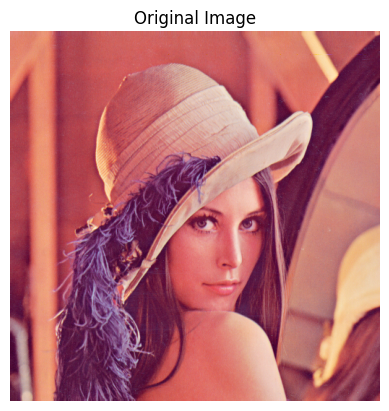

In [ ]:
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

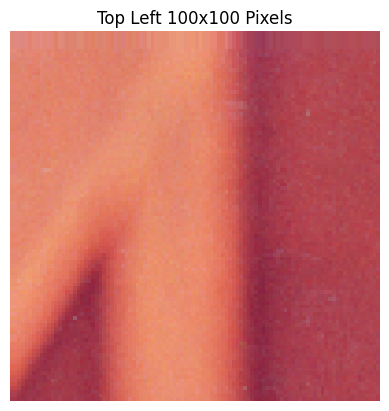

In [ ]:
img_array = np.array(image)
top_left = img_array[0:100, 0:100]
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

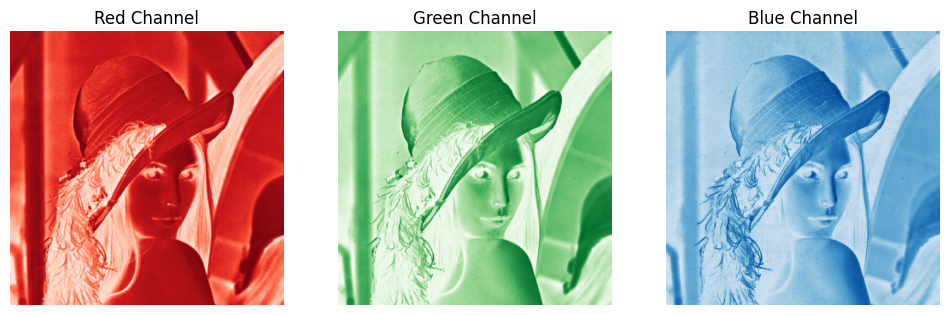

In [ ]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

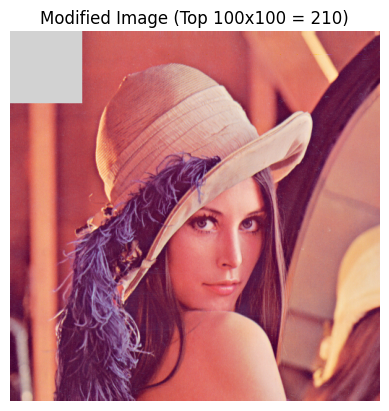

In [ ]:
modified_img = img_array.copy()

modified_img[0:100,0:100] = 210

plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

2.2 Exercise - 2:
Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.
2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.
3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.
4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.
5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cameraman.png to cameraman.png


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

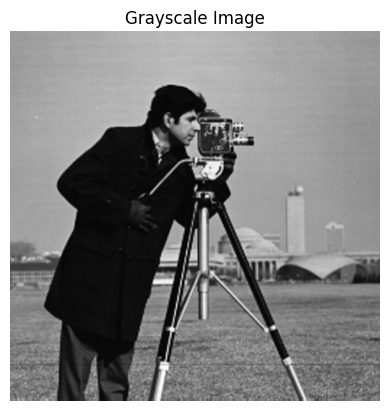

In [ ]:
image = Image.open("cameraman.png")
plt.imshow(image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

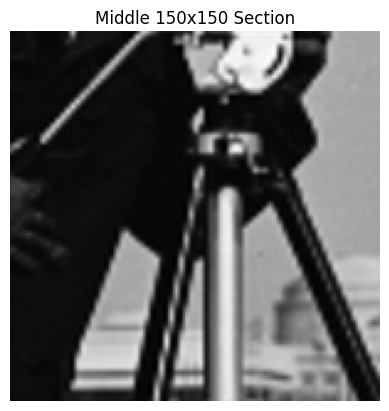

In [ ]:
img_array = np.array(image)

h, w = img_array.shape
center_h = h // 2
center_w = w // 2

middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

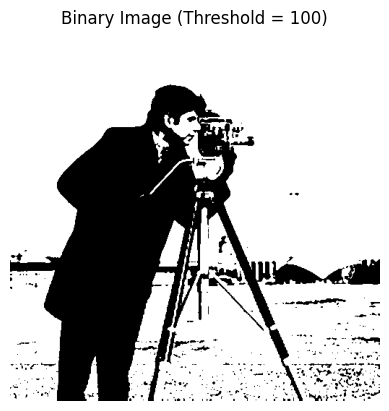

In [ ]:
binary_img = img_array.copy()
binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

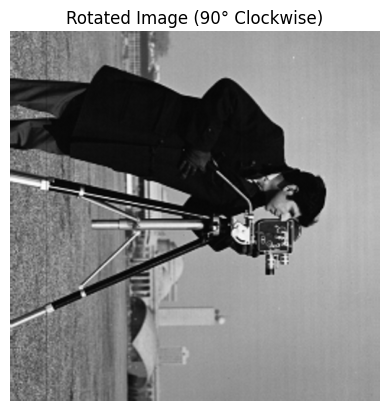

In [ ]:
rotated_image = image.rotate(-90)

plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

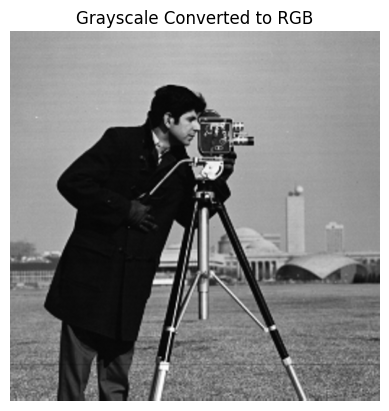

In [ ]:
rgb_image = image.convert("RGB")

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.
In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.
1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.
2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.
3. Reconstruction and Experiment:
• Reconstruction: Transform the original data by multiplying it with the selected eigenvectors(PCs) to obtain a lower-dimensional representation.
• Experiments: Pick Four different combination of principal components with various explained variance value and compare the result.
• Display the Results and Evaluate.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving lena_gray.gif to lena_gray (1).gif


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

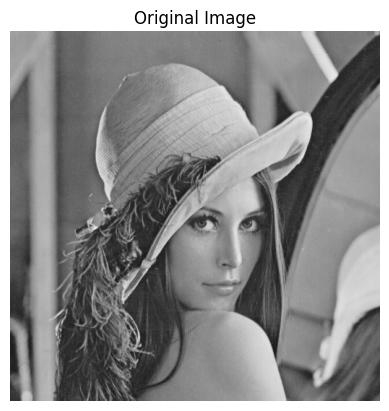

In [ ]:
image = Image.open("lena_gray.gif")
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

img_array = np.array(image)
x = img_array - np.mean(img_array, axis = 0)

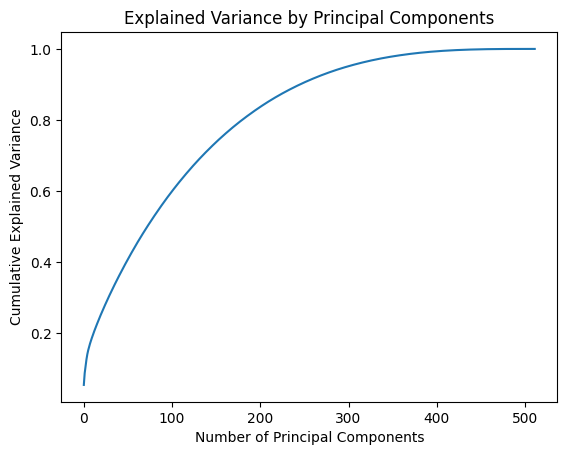

In [ ]:
cov_matrix = np.cov(x, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.show()

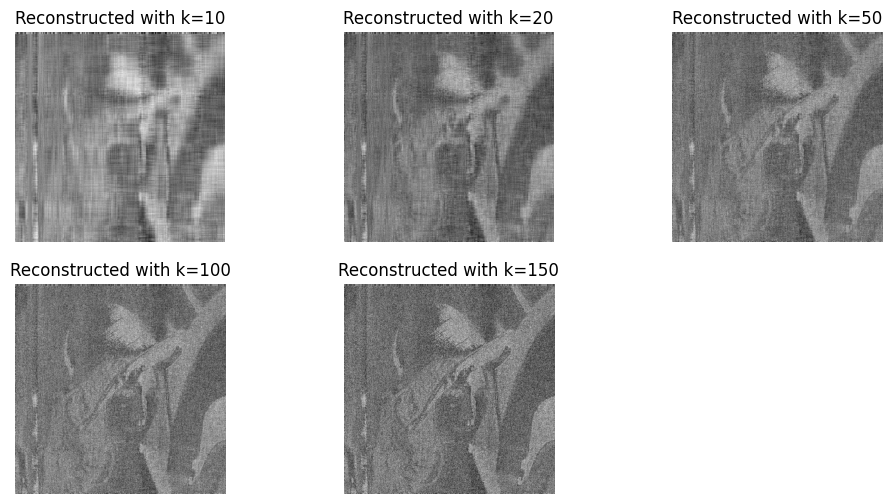

In [ ]:
def reconstruct_image(X, eigenvectors, k):
    # Select top k eigenvectors
    top_eigenvectors = eigenvectors[:, :k]
    # Project data onto reduced space
    X_reduced = np.dot(X, top_eigenvectors)
    # Reconstruct back to original space
    X_reconstructed = np.dot(X_reduced, top_eigenvectors.T)
    return X_reconstructed

k_values = [10, 20, 50, 100, 150]
plt.figure(figsize=(12,6))

for i, k in enumerate(k_values, 1):
    recon = reconstruct_image(x, eigenvectors, k)
    plt.subplot(2,3,i)
    plt.imshow(recon, cmap="gray")
    plt.title(f"Reconstructed with k={k}")
    plt.axis("off")

plt.show()